# Jet energy loss and the wake: hadron level

The hadron-level counterpart of [`wake_observables.ipynb`](wake_observables.ipynb). The figures
come from **`wake_hadrons.h5`**, which [`wake_hadrons.py`](wake_hadrons.py) writes in one pass
over the hadron files of a production (about 5 min for 300 events on 10 cores):

    python wake_hadrons.py /path/to/production -j 10 -o /path/to/production/wake_hadrons.h5

The parton- and hydro-level side (the deposit per event and per shower, the freeze-out times)
comes from the `wake_observables.h5` next to it. So this notebook opens neither the pair files
nor the hadron files.

| source | hadron file | what |
|---|---|---|
| **bkg** | `_hadrons_bulk_bg.h5` | iSS on the background surface (MUSIC_1, no jet) |
| **bkg + wake** | `_hadrons_bulk_jet.h5` | iSS on the jet leg's surface (MUSIC_2, with the liquefier source) |
| **fragments** | `_hadrons_jet_frag.h5` | ColorlessHadronization of the surviving partons |

The **wake** is ⟨bkg + wake⟩ − ⟨bkg⟩. Each event is compared with its own background, and each
leg is averaged over its oversamples (400 per jet leg, 2000 per background here). The
**medium-modified jet** is fragments + wake. All angles are measured from the event's
**leading initiator**, the highest-pT parton that starts a shower. Δφ = 0 points along it, and
its partner is near Δφ = π. These are hadron momenta, unlike the spatial angles in §8 of
`wake_observables.ipynb`.

What the file holds per event and source (sample means and the variance of each mean):

| histogram | axes | quantities |
|---|---|---|
| `jetframe` | Δη, Δφ, pT (charged) | N, Σ pT |
| `dR` | {charged, visible}, ΔR, pT | N, Σ pT, Σ E |
| `spectra` | {near, away}, species, pT at \|y\| < 1 | N |
| `totals` | {all, charged}, \|η\| band, pT | N, E, pT, pT cos Δφ, pT sin Δφ, pz, p·n |

**Sampling errors.** For independently sampled legs, the background's noise is taken as fully
correlated among the events that share it, and the jet legs and fragments as independent. With
common seeds (`hadronize.py --common-seeds` or `--correlated`), the jet legs of the events that
share a background draw its random numbers sample by sample. They are then correlated with each
other and, with `--correlated`, with the background, so their noise largely cancels in the wake.
`wake_hadrons.py` stores batch means for such files: the jet leg and the wake, over aligned blocks
of samples (`hist/<name>/{jet,wake}/batch`). For the bkg + wake and wake curves, `stack()` then takes the spread of the batch
means, with the events of each background summed first. That spread holds all these correlations,
across bins too. The bkg and fragment errors stay as for independent legs. The first code cell
prints which case applies.

"visible" means every particle except neutrinos. `hadronize.py --eta-max` and `--charged` store only
part of the hadrons. The first code cell then warns, because "all" means "all inside the cut": at
\|η\| < 2, the energy balance of §2 misses the forward hadrons and the beam remnants. "all" includes neutrinos, which the energy
balance needs. The \|η\| > 5 band of `totals` holds ColorlessHadronization's beam remnants
(√s/6 = 33 GeV each, pT ≈ 0.3 GeV), which are not part of the jet.

> **Bad runs.** A leg that never froze out has no real freeze-out surface, so its hadrons, and
> the wake of every event that uses it, are meaningless. In `AuAu_0_10_pth10-40_eta06_gridnorm`
> that is the background of job 0002 (MUSIC ran to its maximum time, see the analysis README).
> `wake_hadrons.py` applies the test of `wake_observables.py` (the hottest cell of the last
> stored frame is above 1.5 e_fo, read from the pair file). It adds a hadron-level test of its
> own: the background's multiplicity and freeze-out cells must be within 20% of the jet leg's.
> Both catch job 0002. Its events are not histogrammed, and §1 shows the checks.

In [1]:
%matplotlib inline
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROD = "/home/putschke/FNO_Hydro_Data/AuAu_0_10_pth10-40_eta06_c1"
PATH = os.environ.get("WAKE_HAD", os.path.join(PROD, "wake_hadrons.h5"))
WO_PATH = os.environ.get("WAKE_OBS", os.path.join(os.path.dirname(PATH), "wake_observables.h5"))

# --- the visual language of wake_observables.ipynb: assigned colours + markers per source ----
SRC_C = {"bg": "0.45", "jet": "#0072B2", "wake": "#009E73", "frag": "#D55E00", "full": "#CC79A7"}
SRC_M = {"bg": "o", "jet": "s", "wake": "^", "frag": "D", "full": "v"}
LABEL = {"bg": "bkg", "jet": "bkg + wake", "wake": "wake", "frag": "jet fragments",
         "full": "fragments + wake"}
BIN_C = ["#0072B2", "#009E73", "#E69F00", "#D55E00", "#CC79A7"]
BIN_M = ["o", "s", "^", "D", "v"]
CMAP_DIFF = "RdBu_r"


def tidy(ax, xlabel=None, ylabel=None, title=None):
    """Recessive grid and spines, so the data is the most prominent thing in the frame."""
    ax.grid(True, alpha=0.25, lw=0.6)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if title: ax.set_title(title, fontsize=10)
    return ax


plt.rcParams.update({"figure.dpi": 110, "font.size": 9.5, "axes.titlesize": 10,
                     "legend.frameon": False})
PI_TICKS = ([-np.pi / 2, 0, np.pi / 2, np.pi, 3 * np.pi / 2],
            [r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$"])

# --- wake_hadrons.h5 ---------------------------------------------------------------------------
SOURCES = ("jet", "bg", "frag")
AXES = {"jetframe": ("deta", "dphi", "pt"), "dR": ("group", "dR", "pt"),
        "spectra": ("region", "species", "pt"), "totals": ("group", "band", "pt")}
with h5py.File(PATH, "r") as f:
    A = dict(f.attrs)
    FILES = [os.path.basename(s.decode()) for s in f["files"][:]]
    E = pd.DataFrame({k: f["events"][k][:] for k in f["events"]})
    QN = {n: list(f[f"hist/{n}"].attrs["quantities"]) for n in f["hist"]}
    HIST = {n: {s: {p: f[f"hist/{n}/{s}/{p}"][:] for p in ("mean", "var", "batch")
                    if p in f[f"hist/{n}/{s}"]}
                for s in SOURCES + ("wake",) if s in f[f"hist/{n}"]} for n in f["hist"]}
E["stem"] = [FILES[i] for i in E.file]
PT_E, DETA_E, DPHI_E, DR_E = A["pt_edges"], A["deta_edges"], A["dphi_edges"], A["dR_edges"]
BANDS, SPT_E = A["eta_bands"], A["spec_pt_edges"]
SPECIES = list(A["species"])
PT_C = 0.5 * (PT_E[:-1] + np.minimum(PT_E[1:], 40.0))
G = E.usable.to_numpy()                      # the events every figure uses

# --- wake_observables.h5: the parton- and hydro-level side, joined on (pair file, event) -----
with h5py.File(WO_PATH, "r") as f:
    tab = lambda g: pd.DataFrame({k: f[g][k][:] for k in f[g]})
    WE, WS, WD = tab("events"), tab("showers"), tab("droplets")
    WFILES = [os.path.basename(s.decode()) for s in f["files"][:]]
row = {(WFILES[fi], int(ev)): i for i, (fi, ev) in enumerate(zip(WE.file, WE.ev))}
E["wo_row"] = [row.get((f"{s}.h5", int(ev)), -1) for s, ev in zip(E.stem, E.ev)]
assert (E.wo_row >= 0).all(), "events missing from wake_observables.h5"
for c in ("E_inj_hydro", "E_drop_injected", "E_dep_graph", "E_surv", "tau_fo_jet", "tau_fo_bg",
          "psi2", "eps2"):
    E[c] = WE[c].to_numpy()[E.wo_row]
E["dtau_fo"] = E.tau_fo_jet - E.tau_fo_bg
# the leading initiator's shower at parton level
lead = WS.set_index(["event", "shower"])
key = list(zip(E.wo_row, E.lead_shower.astype(int)))
for c in ("E0", "pT0", "E_dep_graph", "E_surv", "E_surv_R04", "L", "tau_dep_mean"):
    E[f"lead_{c}"] = lead[c].reindex(key).to_numpy()
# energy-weighted deposition time of what MUSIC_2 received
pos = WD.E_inj.clip(lower=0)
tdep = (WD.tau_dep * pos).groupby(WD.event).sum() / pos.groupby(WD.event).sum().clip(1e-9)
E["tau_dep"] = tdep.reindex(E.wo_row).to_numpy()
assert np.allclose(E.E_ini, WE.E_ini.to_numpy()[E.wo_row], rtol=1e-6), "initiators differ"

# Weights, as in wake_observables.ipynb: unweighted by default (see there)
USE_XSEC_WEIGHTS = False
n_bin = E.groupby("pthat_bin").size()
E["w_xsec"] = (E.groupby("pthat_bin").sigma_bin.transform("mean") /
               E.pthat_bin.map(n_bin)) * E.event_weight
E["w_xsec"] /= E.w_xsec[G].mean()
E["w"] = E.w_xsec if USE_XSEC_WEIGHTS else 1.0
BG_GROUP = (E.file * 10000 + E.bg_unit).to_numpy()
# common-seed files: batch means of the jet leg and the background (see the introduction)
HAS_B = E.batched.to_numpy() if "batched" in E else np.zeros(len(E), bool)
N_BATCH = int(A.get("batches", 0))


# --- projections, stacking, errors -------------------------------------------------------------
def proj(name, q, keep=(), **sel):
    """Per event and source: histogram ``name``, quantity ``q``, bins selected with ``sel``
    (axis -> index, slice, index list or bool mask), summed over every axis not in ``keep``.
    -> {source: (mean (n_ev, *kept), var, batch (n_ev, N_BATCH, *kept) or None)}, and
    'wake': (None, None, batch) with batch means. Variances add over bins (independent
    bins); batch means keep the correlations between bins."""
    axes = AXES[name]
    out = {}
    for s in HIST[name]:
        res = []
        for part in ("mean", "var", "batch"):
            if part not in HIST[name][s]:
                res.append(None)
                continue
            a = HIST[name][s][part][:, QN[name].index(q)]
            o = 2 if part == "batch" else 1          # batch: (event, batch, *axes)
            if part != "batch":
                a = a.astype(np.float64)
            for i, ax in enumerate(axes):
                if ax in sel:
                    ix = sel[ax]
                    ix = (np.flatnonzero(ix) if np.asarray(ix).dtype == bool
                          else np.atleast_1d(np.arange(a.shape[o + i])[ix]))
                    a = np.take(a, ix, axis=o + i)
            res.append(a.sum(axis=tuple(o + i for i, ax in enumerate(axes) if ax not in keep),
                             dtype=np.float64))
        out[s] = tuple(res)
    return out


PARTS = {"bg": ("bg",), "jet": ("jet",), "frag": ("frag",), "wake": ("jet", "bg"),
         "full": ("jet", "bg", "frag")}
SIGN = {"jet": 1.0, "bg": -1.0, "frag": 1.0}


def per_event(p, key):
    """Per-event mean of source ``key`` (bg, jet, frag, wake, full)."""
    if key in ("bg", "jet", "frag"):
        return p[key][0]
    return sum(SIGN[s] * p[s][0] for s in PARTS[key])


def batched(p, key):
    """Whether the error of ``key`` comes from batch means (common-seed files)."""
    return key in ("jet", "wake", "full") and "wake" in p and HAS_B.any()


def batch_values(p, key):
    """Per event and batch: the jet leg (key 'jet') or jet leg - background (wake, full)."""
    return p["jet"][2] if key == "jet" else p["wake"][2]


def stack(p, key, ev=None, w=None):
    """Weighted mean over the events ``ev`` (default: all usable) and its sampling error.
    Independent legs: several events share one background, and its noise enters them fully
    correlated (an upper bound; it is ~1/5 of the jet leg's with 5x the samples). With batch
    means (common seeds), the jet leg and the wake take the spread of the batch means of each
    background's events summed, which holds their correlations; the bkg as before."""
    ev = G if ev is None else (np.asarray(ev, bool) & G)
    w = (E.w.to_numpy() if w is None else np.asarray(w, float)) * ev
    W = w / w.sum()
    mean = np.tensordot(W, np.nan_to_num(per_event(p, key)), axes=1)
    var = 0.0
    use_b = HAS_B & ev if batched(p, key) else np.zeros(len(W), bool)
    for s in PARTS[key]:
        v = np.nan_to_num(p[s][1])
        Ws = W * ~use_b if s in ("jet", "bg") else W   # batched events: below
        if s == "bg":
            sd = np.sqrt(v) * Ws.reshape((-1,) + (1,) * (v.ndim - 1))
            var = var + sum(sd[BG_GROUP == g].sum(0) ** 2 for g in np.unique(BG_GROUP[ev]))
        else:
            var = var + np.tensordot(Ws ** 2, v, axes=1)
    if use_b.any():
        X = np.nan_to_num(batch_values(p, key)[use_b])
        X = X * W[use_b].reshape((-1,) + (1,) * (X.ndim - 1))
        grp = BG_GROUP[use_b]
        o = np.argsort(grp, kind="stable")
        starts = np.flatnonzero(np.r_[True, np.diff(grp[o]) != 0])
        S = np.add.reduceat(X[o], starts, axis=0)          # (background, batch, *kept)
        var = var + S.var(1, ddof=1).sum(0) / S.shape[1]
    return mean, np.sqrt(var)


def stack_over(p, key, over, ev=None, w=None):
    """stack() of the sum over the bins ``over`` of the (one) kept axis."""
    if not batched(p, key):                     # independent bins, as for independent legs
        m, e = stack(p, key, ev, w)
        return m[over].sum(), np.sqrt((e[over] ** 2).sum())
    return stack({s: tuple(None if a is None else a[..., over].sum(-1) for a in v)
                  for s, v in p.items()}, key, ev, w)


def ev_err(p, key):
    """Per event: the sampling error of source ``key``."""
    var = sum(np.nan_to_num(p[s][1]) for s in PARTS[key])
    if batched(p, key):
        X = batch_values(p, key)
        vb = X.var(1, ddof=1) / X.shape[1] + (np.nan_to_num(p["frag"][1]) if key == "full"
                                                else 0.0)
        var = np.where(HAS_B.reshape((-1,) + (1,) * (vb.ndim - 1)), vb, var)
    return np.sqrt(var)


def boot(fn, n=300, seed=7):
    """Error of fn(weights) from resampling production files (a file shares its background
    across its events, so files are the independent units)."""
    rng = np.random.default_rng(seed)
    files = np.unique(E.file[G])
    base = E.w.to_numpy() * G
    vals = []
    for _ in range(n):
        c = np.bincount(rng.integers(0, len(files), len(files)), minlength=len(files))
        mult = pd.Series(c, index=files).reindex(E.file).fillna(0).to_numpy()
        vals.append(fn(base * mult))
    return float(np.nanstd(vals))


def wmean(x, w=None):
    w = (E.w.to_numpy() * G) if w is None else w
    x = np.asarray(x, float)
    ok = np.isfinite(x) & (w > 0)
    return float(np.sum(w[ok] * x[ok]) / np.sum(w[ok]))


def profile(x, y, edges, w=None, min_n=5):
    """Weighted mean of y and its standard error in bins of x (NaN where < min_n entries)."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    w = np.ones_like(y) if w is None else np.asarray(w, float)
    idx = np.digitize(x, edges) - 1
    k = len(edges) - 1
    mu, err, n = np.full(k, np.nan), np.full(k, np.nan), np.zeros(k, int)
    for i in range(k):
        m = (idx == i) & np.isfinite(y) & np.isfinite(x) & (w > 0)
        n[i] = m.sum()
        if n[i] < min_n:
            continue
        ww = w[m]
        mu[i] = np.average(y[m], weights=ww)
        neff = ww.sum() ** 2 / (ww ** 2).sum()
        err[i] = np.sqrt(np.average((y[m] - mu[i]) ** 2, weights=ww) / neff)
    return 0.5 * (edges[1:] + edges[:-1]), mu, err, n


def plot_profile(ax, x, y, edges, w, **kw):
    c, mu, err, n = profile(x, y, edges, w)
    ok = np.isfinite(mu)
    ax.errorbar(c[ok], mu[ok], yerr=err[ok], capsize=2, lw=1.4, ms=4, **kw)


def draw(ax, x, y, e, key, **kw):
    kw = {"color": SRC_C[key], "marker": SRC_M[key], "label": LABEL[key], "ms": 3.5,
          "lw": 1.3, "capsize": 0, **kw}
    ax.errorbar(x, y, yerr=e, **kw)


N_EV = int(G.sum())
print(f"{os.path.basename(PATH)}: {len(E)} events from {len(FILES)} production files "
      f"(written {A['created']}); usable: {N_EV}")
print(f"samples per event: jet leg {sorted(set(E.n_jet[G]))}, background "
      f"{sorted(set(E.n_bg[G]))}, fragmentations {sorted(set(E.n_frag[G]))}")
# what hadronize.py stored (--eta-max, --charged); older files do not say: nothing cut
ETA_CUT = float(E.eta_max[G].min()) if "eta_max" in E else np.inf
CHARGED_ONLY = bool(E.charged_only[G].any()) if "charged_only" in E else False
if np.isfinite(ETA_CUT):
    print(f"WARNING: the hadron files keep only |eta| < {ETA_CUT:g} (hadronize.py --eta-max). "
          f"'All eta' below means |eta| < {ETA_CUT:g}: the |eta| bands beyond it are empty, the "
          "fragments lack ColorlessHadronization's beam remnants (|eta| > 5), so the energy "
          "balance of §2 does not close, and the jet frame is cut at |deta| ~ "
          f"{ETA_CUT:g} - |eta_jet| (§5, §6).")
if CHARGED_ONLY:
    print("WARNING: the hadron files keep only charged hadrons (hadronize.py --charged): "
          "'all' and 'visible' are charged too, and the identified neutral species are empty.")
if "common_seeds" in E and (E.common_seeds & G).any():
    print(f"common seeds: {int((HAS_B & G).sum())} of {N_EV} usable events with {N_BATCH} batch "
          "means: bkg + wake and wake errors from their spread"
          + ("" if (HAS_B | ~G).all() else "; the others as independent legs"))
else:
    print("independent legs: bkg shared by several events fully correlated, the rest independent")
print("events per pTHat window:", {int(k): int(v) for k, v in E[G].groupby("pthat_bin").size().items()},
      f"; cross-section weights used: {USE_XSEC_WEIGHTS}")
print(f"leading initiator: {(E.lead_pid[G] == 21).mean():.0%} gluons, "
      f"{(E.lead_pid[G].abs() <= 6).mean():.0%} quarks, {(E.lead_pid[G] == 22).mean():.0%} photons; "
      f"pT {E.lead_pt[G].median():.1f} GeV median, |eta| < {E.lead_eta[G].abs().max():.2f}")

wake_hadrons.h5: 1005 events from 67 production files (written 2026-09-29 22:36:47); usable: 1005
samples per event: jet leg [100], background [100], fragmentations [50]
common seeds: 1005 of 1005 usable events with 10 batch means: bkg + wake and wake errors from their spread
events per pTHat window: {0: 335, 1: 335, 2: 335} ; cross-section weights used: False
leading initiator: 50% gluons, 50% quarks, 0% photons; pT 23.9 GeV median, |eta| < 0.60


## 1. The data set and the bad run

Before anything is histogrammed, each event gets four checks (see the script's docstring):

| check | from | fails when |
|---|---|---|
| `jet_hot_last`, `bg_hot_last` | pair file, last stored frame of each leg | max e > 1.5 e_fo: the leg never froze out (the test of `wake_observables.py`) |
| `mult_off` | hadron files | background multiplicity per sample / jet leg's outside [1/1.2, 1.2] |
| `cells_off` | particlize file | background freeze-out cells / jet leg's outside [1/1.2, 1.2] |
| `wo_flag` | `wake_observables.h5` | its `jet_no_freezeout` or `bg_no_freezeout` |

The wake changes the multiplicity by less than 1%. A background whose surface is not a
freeze-out surface has as many hadrons as the whole volume it never finished evolving.

flagged: 0 of 1005 events, in job(s) []

Empty DataFrame
Columns: [events, usable, bg_hot, jet_hot, mult_off, cells_off, wo_flag, log_max_time, mult_ratio, cells_ratio, e_last_bg, e_fo]
Index: []

pair-file test and wake_observables.h5 agree on every event: True
good jobs: bkg / jet-leg multiplicity 0.9850 .. 0.9996, cells 0.9787 .. 0.9993, max e in the background's last frame 0.231 GeV/fm^3 (e_fo = 0.234)


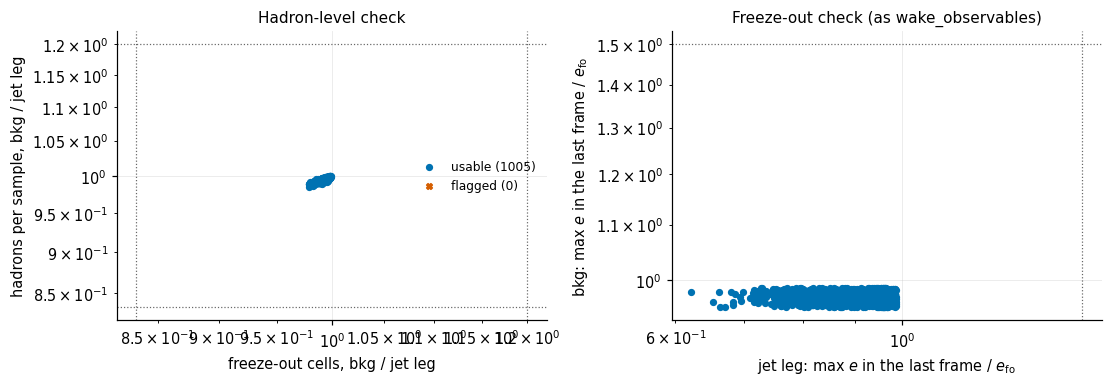

In [2]:
chk = E.groupby("stem").agg(events=("ev", "size"), usable=("usable", "sum"),
                             bg_hot=("bg_hot_last", "sum"), jet_hot=("jet_hot_last", "sum"),
                             mult_off=("mult_off", "sum"), cells_off=("cells_off", "sum"),
                             wo_flag=("wo_flag", lambda x: int((x == 1).sum())),
                             log_max_time=("log_max_time", "max"),
                             mult_ratio=("mult_ratio", "median"), cells_ratio=("cells_ratio", "median"),
                             e_last_bg=("e_last_bg", "max"), e_fo=("e_fo", "first"))
chk.index = [s.rsplit("_", 1)[-1] for s in chk.index]
bad = chk[(chk.usable < chk.events)]
print(f"flagged: {int((~G).sum())} of {len(E)} events, in job(s) {list(bad.index)}\n")
print(bad.round(3).to_string())
agree = ((E.wo_flag == 1) == (E.bg_hot_last | E.jet_hot_last)).all()
print(f"\npair-file test and wake_observables.h5 agree on every event: {agree}")
print(f"good jobs: bkg / jet-leg multiplicity {E.mult_ratio[G].min():.4f} .. {E.mult_ratio[G].max():.4f}, "
      f"cells {E.cells_ratio[G].min():.4f} .. {E.cells_ratio[G].max():.4f}, "
      f"max e in the background's last frame {E.e_last_bg[G].max():.3f} GeV/fm^3 (e_fo = {E.e_fo.iloc[0]:.3f})")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4), constrained_layout=True)
for m, c, lab in ((G, SRC_C["jet"], "usable"), (~G, SRC_C["frag"], "flagged")):
    ax[0].scatter(E.cells_ratio[m], E.mult_ratio[m], s=14, color=c, label=f"{lab} ({m.sum()})",
                  marker="o" if lab == "usable" else "X")
    ax[1].scatter(E.e_last_jet[m] / E.e_fo[m], E.e_last_bg[m] / E.e_fo[m], s=14, color=c,
                  label=lab, marker="o" if lab == "usable" else "X")
for a in ax:
    a.set_xscale("log"); a.set_yscale("log")
for v in (1 / 1.2, 1.2):
    ax[0].axhline(v, color="0.4", ls=":", lw=0.8); ax[0].axvline(v, color="0.4", ls=":", lw=0.8)
ax[1].axhline(1.5, color="0.4", ls=":", lw=0.8); ax[1].axvline(1.5, color="0.4", ls=":", lw=0.8)
tidy(ax[0], "freeze-out cells, bkg / jet leg", "hadrons per sample, bkg / jet leg",
     "Hadron-level check")
tidy(ax[1], r"jet leg: max $e$ in the last frame / $e_\mathrm{fo}$",
     r"bkg: max $e$ in the last frame / $e_\mathrm{fo}$", "Freeze-out check (as wake_observables)")
ax[0].legend(fontsize=8)
plt.show()

## 2. Where the energy goes: the balance at hadron level

Per event, energy is conserved from partons to hadrons:

- the **fragments** carry the surviving partons, $E_\text{surv}$, plus
  ColorlessHadronization's fake beam remnants. A string without a partner quark is closed with
  a remnant quark of √s/6 = 33.3 GeV along the beam (`eCMforHadronization` = 200). The
  string's hadrons spread over all η, so no η cut removes them. Their number $n_\text{rem}$ per
  event is fixed by the partons' colour flow and is the same in every fragmentation. It
  follows from $E_\text{frag} - E_\text{surv}$, which must be a whole multiple of √s/6;
- the **wake** carries what MUSIC_2 received, `E_inj_hydro` (from the kernel-normalized
  droplets). Cooper–Frye on the jet leg's surface returns the fluid's energy, including what
  left the stored output window, which the hydro-level ΔP⁰ of `wake_observables` loses;
- together they give back the initiators, $E_\text{ini}$.

The same holds for the transverse momentum along the leading initiator, $\sum p_T\cos\Delta\varphi$.
Every particle is used here, neutrinos included. The table stacks the usable events. The
first error is the sampling error, the second comes from resampling production files.

In [3]:
allE = proj("totals", "E", group=0)                       # every particle, every band and pT
ptc = proj("totals", "pT_cos", group=0)
# ColorlessHadronization's beam remnants: sqrt(s)/6 each (hadronize.xml eCMforHadronization)
E_REM = 200.0 / 6
n_rem_f = (per_event(allE, "frag") - E.E_surv.to_numpy()) / E_REM
E["n_rem"] = np.round(n_rem_f)
print(f"remnants per event: max |n - round(n)| = {np.nanmax(np.abs(n_rem_f - E.n_rem)[G]):.1e}; "
      f"events with 0 / 1 / 2 / 3: {[int(((E.n_rem == k) & G).sum()) for k in range(4)]}")
noremE = {**allE, "frag": (allE["frag"][0] - E_REM * E.n_rem.to_numpy(), allE["frag"][1])}
pn = proj("totals", "p_n", group=0)


def ratio_err(num_fn, den):
    """sum(w num) / sum(w den) and its file-bootstrap error."""
    f = lambda w: np.nansum(w * num_fn()) / np.nansum(w * den)
    return f(E.w.to_numpy() * G), boot(f)


rows = []
def line(name, p, key, parton, parton_name):
    m, e = stack(p, key)
    x = per_event(p, key)
    b = boot(lambda w: np.nansum(w * x) / np.nansum(w))
    ref = wmean(parton)
    rows.append(dict(quantity=name, hadrons=f"{m:8.2f} +- {e:5.2f} +- {b:5.2f}",
                     parton_or_hydro=f"{ref:8.2f}", reference=parton_name,
                     ratio=f"{m / ref:6.3f}"))


line("E wake (all eta)", allE, "wake", E.E_inj_hydro, "E_inj_hydro (MUSIC_2 received)")
line("E wake (all eta)", allE, "wake", E.E_dep_graph, "E_dep (graph: absorbed+missing-holes)")
line("E fragments - n_rem sqrt(s)/6", noremE, "frag", E.E_surv, "E_surv (surviving partons)")
line("E fragments - remnants + wake", noremE, "full", E.E_ini, "E_ini (initiators)")
line("pT.cos(dphi) fragments + wake", ptc, "full", E.pT_ini_par, "initiators")
print(f"per event, {N_EV} usable events [GeV]; hadrons: mean +- sampling +- files\n")
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nbeam remnants of ColorlessHadronization: {wmean(E.n_rem * E_REM):.1f} GeV per event in the fragments")

remnants per event: max |n - round(n)| = 5.0e-01; events with 0 / 1 / 2 / 3: [911, 0, 0, 0]
per event, 1005 usable events [GeV]; hadrons: mean +- sampling +- files

                     quantity                    hadrons parton_or_hydro                             reference  ratio
             E wake (all eta)    28.89 +-  0.16 +-  0.42           40.88        E_inj_hydro (MUSIC_2 received)  0.707
             E wake (all eta)    28.89 +-  0.16 +-  0.42           40.93 E_dep (graph: absorbed+missing-holes)  0.706
E fragments - n_rem sqrt(s)/6    34.18 +-  0.05 +-  0.61           32.78            E_surv (surviving partons)  1.043
E fragments - remnants + wake    63.07 +-  0.16 +-  0.54           73.71                    E_ini (initiators)  0.856
pT.cos(dphi) fragments + wake     0.98 +-  0.05 +-  0.12            0.63                            initiators  1.554

beam remnants of ColorlessHadronization: -3.3 GeV per event in the fragments


### The wake's energy by pseudorapidity

The wake's energy per |η| band, against the droplets MUSIC_2 received in the same band of
**space-time** rapidity $|\eta_s|$. The two are not the same variable. The wake flows out
longitudinally, so a match band by band is not expected. Still, if the deposit were mostly at
large |η_s|, the forward hadrons would have to carry it. Before the kernel normalization, those
droplets are where the injected energy was wrong. The fragments' forward bands hold
the remnant strings, and the right-hand figure below shows how far in they reach.

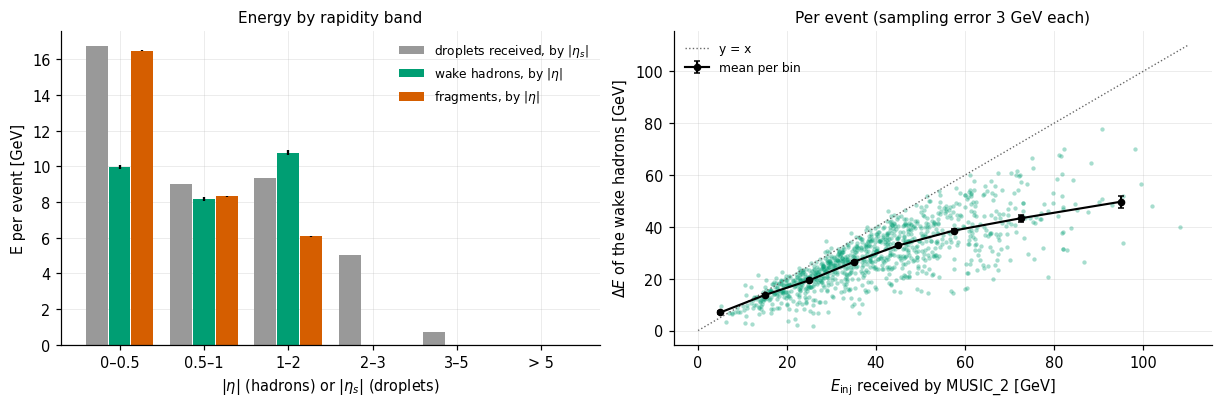

wake energy fraction per |eta| band: {'0–0.5': np.float64(0.345), '0.5–1': np.float64(0.282), '1–2': np.float64(0.373), '2–3': np.float64(0.0), '3–5': np.float64(0.0), '> 5': np.float64(0.0)}
droplet energy fraction per |eta_s| band: {'0–0.5': np.float64(0.409), '0.5–1': np.float64(0.221), '1–2': np.float64(0.229), '2–3': np.float64(0.124), '3–5': np.float64(0.018), '> 5': np.float64(0.0)}


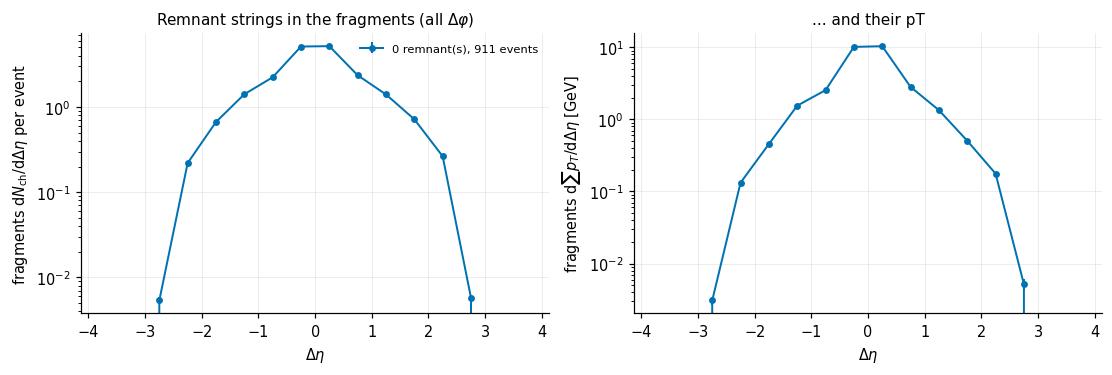

In [4]:
bandE = proj("totals", "E", keep=("band",), group=0)
m_w, e_w = stack(bandE, "wake")
m_f, e_f = stack(bandE, "frag")
# droplets MUSIC_2 received, per |eta_s| band, per usable event
d = WD[WD.event.isin(E.wo_row[G])]
idx = np.clip(np.searchsorted(BANDS, np.abs(np.nan_to_num(d.eta)), side="right") - 1, 0, len(BANDS) - 2)
drop = np.bincount(idx, weights=d.E_inj, minlength=len(BANDS) - 1) / N_EV
labels = [f"{BANDS[i]:g}–{BANDS[i + 1]:g}" if BANDS[i + 1] < 100 else f"> {BANDS[i]:g}"
          for i in range(len(BANDS) - 1)]
x = np.arange(len(labels))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
ax[0].bar(x - 0.27, drop, 0.26, color="0.6", label=r"droplets received, by $|\eta_s|$")
ax[0].bar(x, m_w, 0.26, yerr=e_w, color=SRC_C["wake"], label=r"wake hadrons, by $|\eta|$")
ax[0].bar(x + 0.27, m_f, 0.26, yerr=e_f, color=SRC_C["frag"], label=r"fragments, by $|\eta|$")
ax[0].set_xticks(x, labels)
ax[0].axhline(0, color="0.3", lw=0.7)
tidy(ax[0], r"$|\eta|$ (hadrons) or $|\eta_s|$ (droplets)", "E per event [GeV]",
     "Energy by rapidity band")
ax[0].legend(fontsize=8)
# per event: the wake's energy against what MUSIC_2 received
x_ev, y_ev = E.E_inj_hydro[G], per_event(allE, "wake")[G]
ax[1].scatter(x_ev, y_ev, s=8, color=SRC_C["wake"], alpha=0.35, lw=0)
edges = np.array([0, 10, 20, 30, 40, 50, 65, 80, 110])
plot_profile(ax[1], x_ev, y_ev, edges, E.w[G], color="k", marker="o", label="mean per bin")
lim = [0, 110]
ax[1].plot(lim, lim, color="0.4", ls=":", lw=0.9, label="y = x")
err_ev = ev_err(allE, "wake")[G]
tidy(ax[1], r"$E_\mathrm{inj}$ received by MUSIC_2 [GeV]", r"$\Delta E$ of the wake hadrons [GeV]",
     f"Per event (sampling error {np.median(err_ev):.0f} GeV each)")
ax[1].legend(fontsize=8)
plt.show()
print("wake energy fraction per |eta| band:", dict(zip(labels, np.round(m_w / m_w.sum(), 3))))
print("droplet energy fraction per |eta_s| band:", dict(zip(labels, np.round(drop / drop.sum(), 3))))

# what the remnant strings put into the jet frame: fragments of events with 0, 1, 2 remnants
deta_c = 0.5 * (DETA_E[1:] + DETA_E[:-1])
fig, ax = plt.subplots(1, 2, figsize=(10, 3.3), constrained_layout=True)
pfN = proj("jetframe", "N", keep=("deta",))
pfP = proj("jetframe", "pT", keep=("deta",))
for k in range(3):
    sel = (E.n_rem == k).to_numpy()
    if (sel & G).sum() < 5:
        continue
    for j, pp in enumerate((pfN, pfP)):
        m, e = stack(pp, "frag", ev=sel)
        ax[j].errorbar(deta_c, m / np.diff(DETA_E), e / np.diff(DETA_E), color=BIN_C[k], marker=BIN_M[k],
                       ms=3.5, lw=1.3, label=f"{k} remnant(s), {int((sel & G).sum())} events")
tidy(ax[0], r"$\Delta\eta$", r"fragments $\mathrm{d}N_\mathrm{ch}/\mathrm{d}\Delta\eta$ per event",
     "Remnant strings in the fragments (all $\\Delta\\varphi$)")
tidy(ax[1], r"$\Delta\eta$", r"fragments $\mathrm{d}\sum p_T/\mathrm{d}\Delta\eta$ [GeV]",
     "... and their pT")
ax[0].set_yscale("log"); ax[1].set_yscale("log")
ax[0].legend(fontsize=7.5)
plt.show()

## 3. The wake's pT spectrum

Charged hadrons at |y| < 1. **Near** is the hemisphere of the leading initiator
(|Δφ| < π/2), **away** the other one, where the partner jet also deposits. The wake is a small
change on top of a large background: ~760 charged hadrons per unit rapidity. Its effect is
largest at low pT. The fragments take over above a crossing pT.

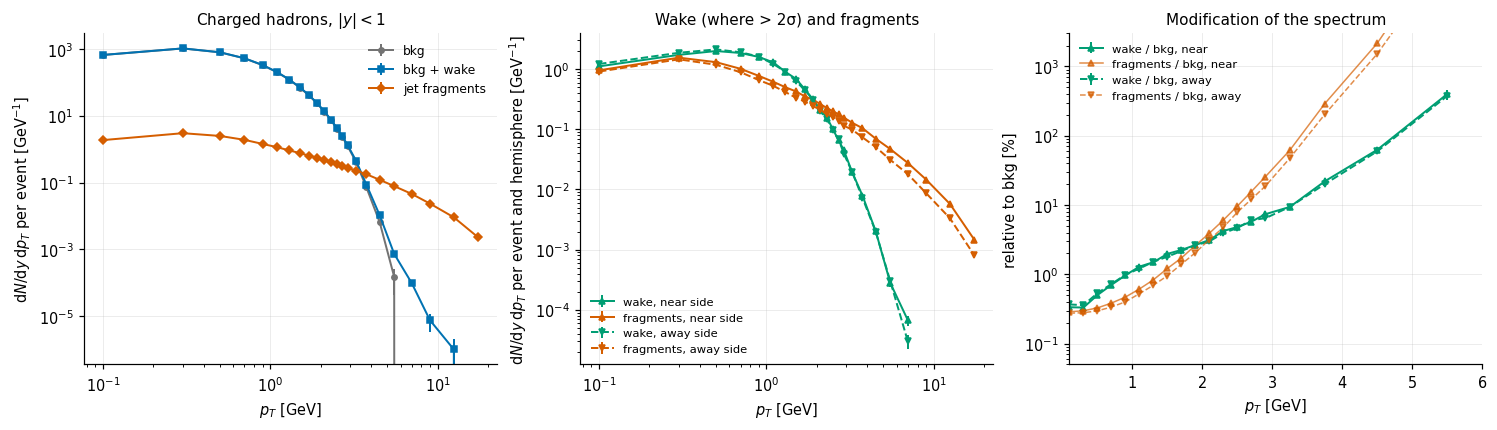

|y| < 1, charged, per event: bkg 1539.1, wake +10.21 +- 0.12 (near +5.05, away +5.16), fragments 7.81
<pT> [GeV]: bkg 0.548, wake 0.861, fragments 1.671
fragments exceed the wake from pT ~ 2.1 GeV


In [5]:
isp = SPECIES.index("charged")
spn = proj("spectra", "N", keep=("region", "pt"), species=isp)
spa = proj("spectra", "N", keep=("pt",), species=isp)
dpt = np.diff(SPT_E)
c = 0.5 * (SPT_E[1:] + SPT_E[:-1])
norm = dpt * 2 * A["y_spectra"]          # per GeV per unit y
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)
for key in ("bg", "jet", "frag"):
    m, e = stack(spa, key)
    draw(ax[0], c, m / norm, e / norm, key)
ax[0].set_yscale("log"); ax[0].set_xscale("log")
tidy(ax[0], r"$p_T$ [GeV]", r"$\mathrm{d}N/\mathrm{d}y\,\mathrm{d}p_T$ per event [GeV$^{-1}$]",
     r"Charged hadrons, $|y| < 1$")
ax[0].legend(fontsize=8)
for r, (ls, mk) in enumerate((("-", "^"), ("--", "v"))):
    m, e = stack(spn, "wake")
    ok = m[r] > 2 * e[r]
    ax[1].errorbar(c[ok], m[r][ok] / norm[ok], e[r][ok] / norm[ok], color=SRC_C["wake"], ls=ls,
                   marker=mk, ms=3.5, lw=1.3, label=f"wake, {A['regions'][r]} side")
    mf, ef = stack(spn, "frag")
    ax[1].errorbar(c, mf[r] / norm, ef[r] / norm, color=SRC_C["frag"], ls=ls, marker=mk,
                   ms=3.5, lw=1.3, label=f"fragments, {A['regions'][r]} side")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
tidy(ax[1], r"$p_T$ [GeV]", r"$\mathrm{d}N/\mathrm{d}y\,\mathrm{d}p_T$ per event and hemisphere [GeV$^{-1}$]",
     "Wake (where > 2σ) and fragments")
ax[1].legend(fontsize=7.5)
mb, eb = stack(spn, "bg")
mw, ew = stack(spn, "wake")
for r, (ls, mk) in enumerate((("-", "^"), ("--", "v"))):
    ok = (mb[r] > 0) & (c < 6)
    ax[2].errorbar(c[ok], 100 * mw[r][ok] / mb[r][ok], 100 * ew[r][ok] / mb[r][ok], color=SRC_C["wake"],
                   ls=ls, marker=mk, ms=3.5, lw=1.3, label=f"wake / bkg, {A['regions'][r]}")
    ax[2].errorbar(c[ok], 100 * stack(spn, "frag")[0][r][ok] / mb[r][ok], color=SRC_C["frag"], ls=ls,
                   marker=mk, ms=3.5, lw=1.0, alpha=0.7, label=f"fragments / bkg, {A['regions'][r]}")
ax[2].set_xscale("linear"); ax[2].set_yscale("log")
ax[2].set_xlim(0.1, 6); ax[2].set_ylim(0.05, 3e3)
tidy(ax[2], r"$p_T$ [GeV]", "relative to bkg [%]", "Modification of the spectrum")
ax[2].legend(fontsize=7.5)
plt.show()

nw, enw = stack(proj("spectra", "N", species=isp), "wake")
nb = stack(proj("spectra", "N", species=isp), "bg")[0]
nf = stack(proj("spectra", "N", species=isp), "frag")[0]
mpt = lambda k: np.sum(stack(spa, k)[0] * c) / np.sum(stack(spa, k)[0])
print(f"|y| < 1, charged, per event: bkg {nb:.1f}, wake {nw:+.2f} +- {enw:.2f} "
      f"(near {mw[0].sum():+.2f}, away {mw[1].sum():+.2f}), fragments {nf:.2f}")
print(f"<pT> [GeV]: bkg {mpt('bg'):.3f}, wake {mpt('wake'):.3f}, fragments {mpt('frag'):.3f}")
cross = c[np.argmax(stack(spa, 'frag')[0] > stack(spa, 'wake')[0])]
print(f"fragments exceed the wake from pT ~ {cross:.1f} GeV")

## 4. Hadrochemistry of the wake

A wake that thermalizes and freezes out with the medium should have the background's
chemistry: the same p/π and K/π (iSS samples both surfaces with one set of freeze-out
parameters), but a harder spectrum because it flows. The jet fragments come from string
fragmentation and have a different chemistry. Yields at |y| < 1, both hemispheres, per event.
Ratio errors come from resampling production files. The pure-hydro spectra (iSS with
resonance decays, no hadronic afterburner) put heavy hadrons at high pT through radial flow,
hence the steep rise of p/π in the background.

                     bkg           wake  jet fragments
K/π        0.186 ± 0.000  0.187 ± 0.005  0.129 ± 0.001
p/π        0.083 ± 0.000  0.093 ± 0.004  0.063 ± 0.001
Λ/π        0.050 ± 0.000  0.053 ± 0.002  0.022 ± 0.000
p̄/p       1.001 ± 0.002  1.115 ± 0.074  0.918 ± 0.010
π/charged  0.766 ± 0.000  0.757 ± 0.004  0.814 ± 0.001

yields per event at |y| < 1: {'pi+': 'wake +3.87, frag 3.21', 'K+': 'wake +0.74, frag 0.42', 'p': 'wake +0.34, frag 0.21', 'pbar': 'wake +0.38, frag 0.19'}


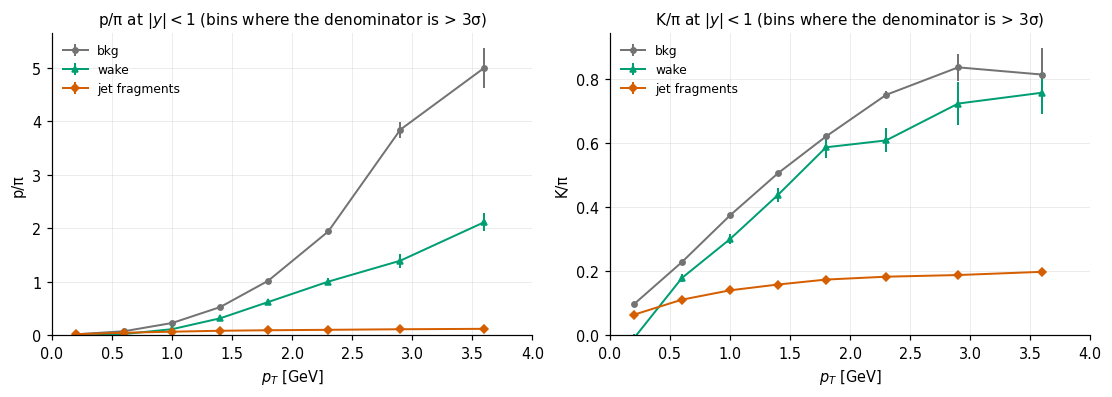

In [6]:
Y = {s: proj("spectra", "N", species=SPECIES.index(s)) for s in SPECIES}
Ypt = {s: proj("spectra", "N", keep=("pt",), species=SPECIES.index(s)) for s in SPECIES}
RATIOS = {"K/π": (("K+", "K-"), ("pi+", "pi-")), "p/π": (("p", "pbar"), ("pi+", "pi-")),
          "Λ/π": (("Lambda+bar",), ("pi+", "pi-")), "p̄/p": (("pbar",), ("p",)),
          "π/charged": (("pi+", "pi-"), ("charged",))}


def ratio(key, num, den, w):
    n = sum(np.nansum(w * per_event(Y[s], key)) for s in num)
    d = sum(np.nansum(w * per_event(Y[s], key)) for s in den)
    return n / d


tab = {}
w0 = E.w.to_numpy() * G
for key in ("bg", "wake", "frag"):
    tab[LABEL[key]] = {r: f"{ratio(key, *nd, w0):.3f} ± {boot(lambda w: ratio(key, *nd, w), n=150):.3f}"
                       for r, nd in RATIOS.items()}
print(pd.DataFrame(tab).to_string())
print("\nyields per event at |y| < 1:",
      {s: f"wake {stack(Y[s], 'wake')[0]:+.2f}, frag {stack(Y[s], 'frag')[0]:.2f}"
       for s in ("pi+", "K+", "p", "pbar")})

# p/pi and K/pi against pT, in coarse pT bins
CE = np.array([0.0, 0.4, 0.8, 1.2, 1.6, 2.0, 2.6, 3.2, 4.0])
grp = np.searchsorted(CE, 0.5 * (SPT_E[1:] + SPT_E[:-1]), side="right") - 1
cc = 0.5 * (CE[1:] + CE[:-1])
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
for j, (rname, (num, den)) in enumerate([("p/π", RATIOS["p/π"]), ("K/π", RATIOS["K/π"])]):
    for key in ("bg", "wake", "frag"):
        n = sum(stack(Ypt[s], key)[0] for s in num)
        d = sum(stack(Ypt[s], key)[0] for s in den)
        en = np.sqrt(sum(stack(Ypt[s], key)[1] ** 2 for s in num))
        ed = np.sqrt(sum(stack(Ypt[s], key)[1] ** 2 for s in den))
        N = np.bincount(grp, weights=n, minlength=len(CE))[: len(cc)]
        D = np.bincount(grp, weights=d, minlength=len(CE))[: len(cc)]
        eN = np.sqrt(np.bincount(grp, weights=en ** 2, minlength=len(CE))[: len(cc)])
        eD = np.sqrt(np.bincount(grp, weights=ed ** 2, minlength=len(CE))[: len(cc)])
        with np.errstate(divide="ignore", invalid="ignore"):
            r = N / D
            er = np.abs(r) * np.sqrt((eN / N) ** 2 + (eD / D) ** 2)
        ok = (D > 3 * eD) & (D > 0)
        draw(ax[j], cc[ok], r[ok], er[ok], key)
    ax[j].set_ylim(bottom=0)
    tidy(ax[j], r"$p_T$ [GeV]", rname, f"{rname} at $|y| < 1$ (bins where the denominator is > 3σ)")
    ax[j].set_xlim(0, 4)
    ax[j].legend(fontsize=8)
plt.show()

## 5. The wake around the jet

Charged hadrons in the frame of the leading initiator. **Top:** Δφ at |Δη| < 1, per pT class.
Look for the wake's excess along the jet, and for a depletion behind it. The depletion is the
diffusion wake, or the holes of the recoils. It sits at Δφ ≈ π, where the partner jet's own
wake also lands. **Bottom:** Δη on the near side, and the (Δη, Δφ) maps of the wake's and
the fragments' pT.

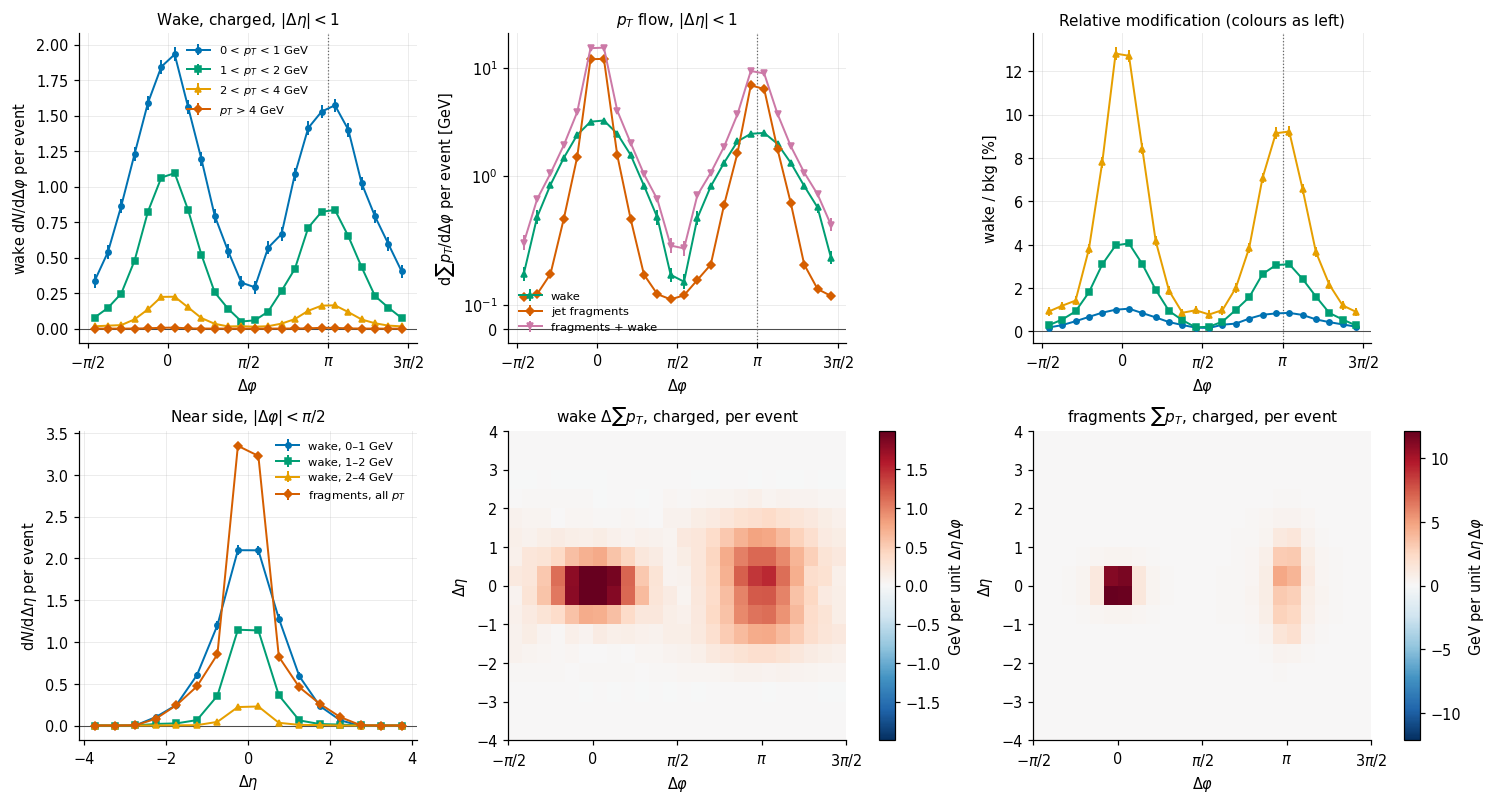

wake, charged, |deta| < 1: near side (|dphi| < pi/3) +4.52 +- 0.04, away side (|dphi - pi| < pi/3) +3.83 +- 0.04 hadrons per event
  0-1 GeV: max at dphi =     7 deg, min at    97 deg (+0.076 +- 0.012)
  1-2 GeV: max at dphi =     7 deg, min at    82 deg (+0.013 +- 0.004)
  2-4 GeV: max at dphi =     7 deg, min at    97 deg (+0.004 +- 0.001)
  4-999 GeV: max at dphi =     7 deg, min at   -83 deg (-0.000 +- 0.000)


In [7]:
dphi_c = 0.5 * (DPHI_E[1:] + DPHI_E[:-1])
deta_c = 0.5 * (DETA_E[1:] + DETA_E[:-1])
mid_eta = np.abs(deta_c) < 1.0
PTCLS = [(0.0, 1.0), (1.0, 2.0), (2.0, 4.0), (4.0, 1e9)]
cls_mask = lambda lo, hi: (PT_E[:-1] >= lo) & (PT_E[:-1] < hi)
fig, ax = plt.subplots(2, 3, figsize=(13.5, 7.2), constrained_layout=True)
for i, (lo, hi) in enumerate(PTCLS):
    p = proj("jetframe", "N", keep=("dphi",), deta=mid_eta, pt=cls_mask(lo, hi))
    m, e = stack(p, "wake")
    lab = f"{lo:g} < $p_T$ < {hi:g} GeV" if hi < 100 else f"$p_T$ > {lo:g} GeV"
    ax[0, 0].errorbar(dphi_c, m / np.diff(DPHI_E), e / np.diff(DPHI_E), color=BIN_C[i],
                      marker=BIN_M[i], ms=3.5, lw=1.3, label=lab)
pN = proj("jetframe", "N", keep=("dphi",), deta=mid_eta)
pP = proj("jetframe", "pT", keep=("dphi",), deta=mid_eta)
for key in ("wake", "frag", "full"):
    m, e = stack(pP, key)
    draw(ax[0, 1], dphi_c, m / np.diff(DPHI_E), e / np.diff(DPHI_E), key)
mb = stack(pN, "bg")[0]
for i, (lo, hi) in enumerate(PTCLS[:3]):
    p = proj("jetframe", "N", keep=("dphi",), deta=mid_eta, pt=cls_mask(lo, hi))
    m, e = stack(p, "wake")
    b = stack(p, "bg")[0]
    ax[0, 2].errorbar(dphi_c, 100 * m / b, 100 * e / b, color=BIN_C[i], marker=BIN_M[i], ms=3.5, lw=1.3)
tidy(ax[0, 0], r"$\Delta\varphi$", r"wake $\mathrm{d}N/\mathrm{d}\Delta\varphi$ per event",
     r"Wake, charged, $|\Delta\eta| < 1$")
tidy(ax[0, 1], r"$\Delta\varphi$", r"$\mathrm{d}\sum p_T/\mathrm{d}\Delta\varphi$ per event [GeV]",
     r"$p_T$ flow, $|\Delta\eta| < 1$")
tidy(ax[0, 2], r"$\Delta\varphi$", "wake / bkg [%]", "Relative modification (colours as left)")
ax[0, 0].legend(fontsize=7.5); ax[0, 1].legend(fontsize=7.5)
ax[0, 1].set_yscale("symlog", linthresh=0.5)

near = (dphi_c > -np.pi / 2) & (dphi_c < np.pi / 2)
for i, (lo, hi) in enumerate(PTCLS[:3]):
    p = proj("jetframe", "N", keep=("deta",), dphi=near, pt=cls_mask(lo, hi))
    m, e = stack(p, "wake")
    ax[1, 0].errorbar(deta_c, m / np.diff(DETA_E), e / np.diff(DETA_E), color=BIN_C[i],
                      marker=BIN_M[i], ms=3.5, lw=1.3,
                      label=f"wake, {lo:g}–{hi:g} GeV")
pf = proj("jetframe", "N", keep=("deta",), dphi=near)
m, e = stack(pf, "frag")
draw(ax[1, 0], deta_c, m / np.diff(DETA_E), e / np.diff(DETA_E), "frag", label="fragments, all $p_T$")
tidy(ax[1, 0], r"$\Delta\eta$", r"$\mathrm{d}N/\mathrm{d}\Delta\eta$ per event",
     r"Near side, $|\Delta\varphi| < \pi/2$")
ax[1, 0].legend(fontsize=7.5)
for a in list(ax[0]) + [ax[1, 0]]:
    a.axhline(0, color="0.3", lw=0.7)
for a in ax[0]:
    a.set_xticks(*PI_TICKS); a.axvline(np.pi, color="0.4", ls=":", lw=0.8)

p2 = proj("jetframe", "pT", keep=("deta", "dphi"))
cell = np.outer(np.diff(DETA_E), np.diff(DPHI_E))
for j, (key, title) in enumerate((("wake", r"wake $\Delta\sum p_T$"), ("frag", r"fragments $\sum p_T$"))):
    m = stack(p2, key)[0] / cell
    v = np.nanmax(np.abs(m)) if key == "frag" else np.nanpercentile(np.abs(m), 99)
    im = ax[1, 1 + j].pcolormesh(DPHI_E, DETA_E, m, cmap=CMAP_DIFF, vmin=-v, vmax=v, shading="flat")
    fig.colorbar(im, ax=ax[1, 1 + j], label=r"GeV per unit $\Delta\eta\,\Delta\varphi$", fraction=0.05)
    ax[1, 1 + j].set_xticks(*PI_TICKS)
    tidy(ax[1, 1 + j], r"$\Delta\varphi$", r"$\Delta\eta$", title + ", charged, per event")
    ax[1, 1 + j].grid(False)
plt.show()

sel_n = np.abs(dphi_c) < np.pi / 3
sel_a = np.abs(dphi_c - np.pi) < np.pi / 3
(wn, en), (wa, ea) = stack_over(pN, "wake", sel_n), stack_over(pN, "wake", sel_a)
print(f"wake, charged, |deta| < 1: near side (|dphi| < pi/3) {wn:+.2f} +- {en:.2f}, "
      f"away side (|dphi - pi| < pi/3) {wa:+.2f} +- {ea:.2f} hadrons per event")
for lo, hi in PTCLS:
    p = proj("jetframe", "N", keep=("dphi",), deta=mid_eta, pt=cls_mask(lo, hi))
    m, e = stack(p, "wake")
    k_min = np.argmin(m)
    print(f"  {lo:g}-{min(hi, 999):g} GeV: max at dphi = {np.degrees(dphi_c[np.argmax(m)]):5.0f} deg, "
          f"min at {np.degrees(dphi_c[k_min]):5.0f} deg ({m[k_min]:+.3f} +- {e[k_min]:.3f})")

### Isolating the leading jet's own wake

In every event the partner leg deposits too, and its wake lands at Δφ ≈ π, on top of
whatever the leading jet leaves behind. Splitting the events by the leading leg's share of
the event's deposit (`E_dep_graph` of its shower over the event's, from `wake_observables.h5`)
separates the two: where the leading leg deposits most, the away side shows its own diffusion
wake more clearly.

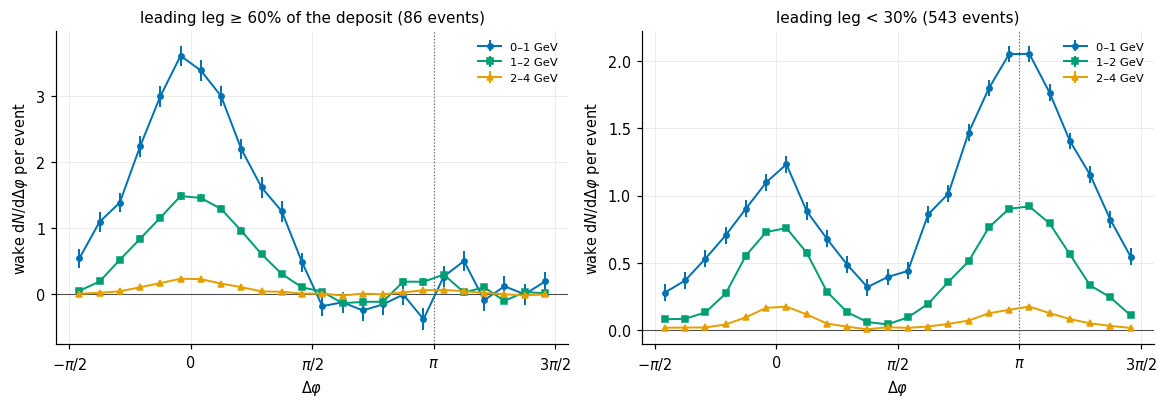

leading leg ≥ 60% of the deposit: wake behind the leading jet (|dphi - pi| < pi/2, |deta| < 1): 0-1 GeV -0.02 +- 0.13 +- 0.16; 1-2 GeV +0.12 +- 0.04 +- 0.08; 2-4 GeV +0.06 +- 0.01 +- 0.02
leading leg < 30%: wake behind the leading jet (|dphi - pi| < pi/2, |deta| < 1): 0-1 GeV +4.03 +- 0.06 +- 0.14; 1-2 GeV +1.51 +- 0.02 +- 0.05; 2-4 GeV +0.23 +- 0.00 +- 0.01
(per event, charged; +- sampling +- files)


In [8]:
share = (E.lead_E_dep_graph / E.E_dep_graph).to_numpy()
E["lead_share"] = share
split = [("leading leg ≥ 60% of the deposit", share >= 0.6), ("leading leg < 30%", share < 0.3)]
fig, ax = plt.subplots(1, 2, figsize=(10.5, 3.6), constrained_layout=True)
for j, (lab, sel) in enumerate(split):
    for i, (lo, hi) in enumerate(PTCLS[:3]):
        p = proj("jetframe", "N", keep=("dphi",), deta=mid_eta, pt=cls_mask(lo, hi))
        m, e = stack(p, "wake", ev=sel)
        ax[j].errorbar(dphi_c, m / np.diff(DPHI_E), e / np.diff(DPHI_E), color=BIN_C[i],
                       marker=BIN_M[i], ms=3.5, lw=1.3, label=f"{lo:g}–{hi:g} GeV")
    ax[j].axhline(0, color="0.3", lw=0.7)
    ax[j].set_xticks(*PI_TICKS); ax[j].axvline(np.pi, color="0.4", ls=":", lw=0.8)
    tidy(ax[j], r"$\Delta\varphi$", r"wake $\mathrm{d}N/\mathrm{d}\Delta\varphi$ per event",
         f"{lab} ({int((sel & G).sum())} events)")
    ax[j].legend(fontsize=7.5)
plt.show()
back = np.abs(dphi_c - np.pi) < np.pi / 2
for lab, sel in split:
    out = []
    for lo, hi in PTCLS[:3]:
        p = proj("jetframe", "N", keep=("dphi",), deta=mid_eta, pt=cls_mask(lo, hi))
        m, e = stack_over(p, "wake", back, ev=sel)
        x = per_event(p, "wake")[:, back].sum(1)
        b = boot(lambda w: np.nansum(w * sel * x) / np.nansum(w * sel))
        out.append(f"{lo:g}-{hi:g} GeV {m:+.2f} +- {e:.2f} +- {b:.2f}")
    print(f"{lab}: wake behind the leading jet (|dphi - pi| < pi/2, |deta| < 1): " + "; ".join(out))
print("(per event, charged; +- sampling +- files)")

## 6. Jet shape and how much of the lost energy comes back within R

The pT of visible particles in annuli of ΔR around the leading initiator, per event:
$\rho(r) = \frac{1}{\delta r}\sum_{r_i \in [r, r+\delta r)} p_{T,i}$. The fragments are the
quenched jet without medium response, and fragments + wake is what a jet finder would see
after an ideal subtraction of the background. **Right:** the pT inside R, cumulative. It is
compared with the leading parton at parton level: its initial pT, what survives within
ΔR < 0.4 (`E_surv_R04`), and how much it deposited. Beyond ΔR ≈ 1.5 (shaded) the partner
jet, its wake and the remnant strings come in, so the shape is not the leading jet's any more.

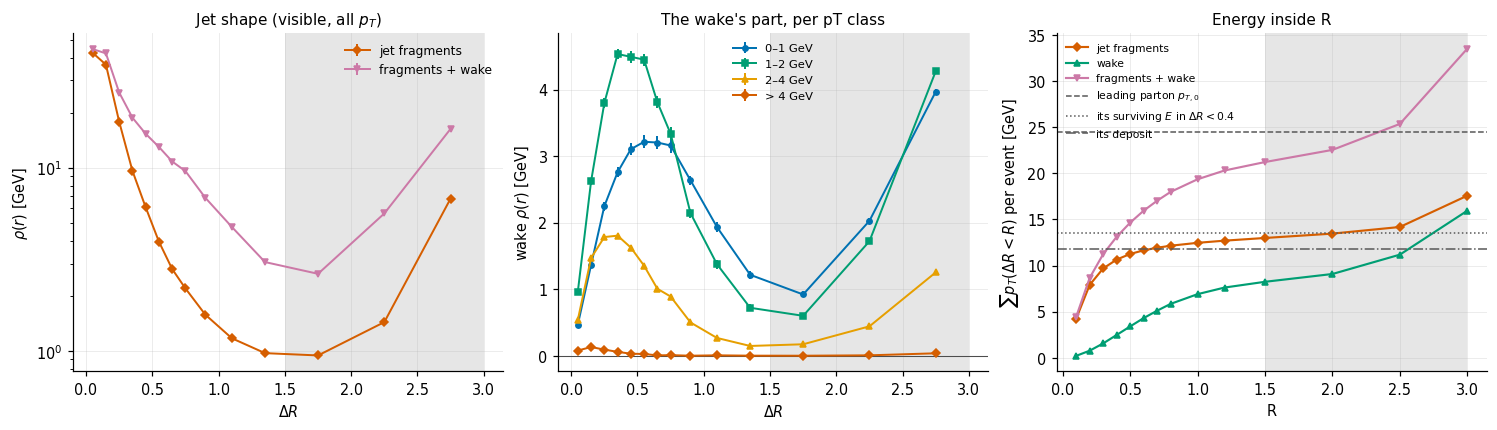

R = 0.2: fragments   7.90, wake  +0.76, fragments + wake   8.66 GeV;  wake / leading deposit +0.06
R = 0.4: fragments  10.65, wake  +2.47, fragments + wake  13.12 GeV;  wake / leading deposit +0.21
R = 0.6: fragments  11.65, wake  +4.30, fragments + wake  15.95 GeV;  wake / leading deposit +0.37
R = 0.8: fragments  12.15, wake  +5.84, fragments + wake  17.99 GeV;  wake / leading deposit +0.50
R = 1.0: fragments  12.47, wake  +6.90, fragments + wake  19.36 GeV;  wake / leading deposit +0.59
R = 1.2: fragments  12.70, wake  +7.61, fragments + wake  20.31 GeV;  wake / leading deposit +0.65
R = 1.5: fragments  12.99, wake  +8.24, fragments + wake  21.23 GeV;  wake / leading deposit +0.70


In [9]:
iv = list(A["groups_dR"]).index("visible")
rc = 0.5 * (DR_E[1:] + DR_E[:-1])
dr = np.diff(DR_E)
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)
pr = proj("dR", "pT", keep=("dR",), group=iv)
for key in ("frag", "full"):
    m, e = stack(pr, key)
    draw(ax[0], rc, m / dr, e / dr, key)
ax[0].set_yscale("log")
for a in ax:
    a.axvspan(1.5, DR_E[-1], color="0.9", zorder=0, lw=0)
tidy(ax[0], r"$\Delta R$", r"$\rho(r)$ [GeV]", "Jet shape (visible, all $p_T$)")
ax[0].legend(fontsize=8)
for i, (lo, hi) in enumerate(PTCLS):
    p = proj("dR", "pT", keep=("dR",), group=iv, pt=cls_mask(lo, hi))
    m, e = stack(p, "wake")
    lab = f"{lo:g}–{hi:g} GeV" if hi < 100 else f"> {lo:g} GeV"
    ax[1].errorbar(rc, m / dr, e / dr, color=BIN_C[i], marker=BIN_M[i], ms=3.5, lw=1.3, label=lab)
ax[1].axhline(0, color="0.3", lw=0.7)
tidy(ax[1], r"$\Delta R$", r"wake $\rho(r)$ [GeV]", "The wake's part, per pT class")
ax[1].legend(fontsize=7.5)
cum = {k: np.cumsum(stack(pr, k)[0]) for k in ("frag", "wake", "full")}
for k in ("frag", "wake", "full"):
    ax[2].plot(DR_E[1:], cum[k], color=SRC_C[k], marker=SRC_M[k], ms=3.5, lw=1.4, label=LABEL[k])
for val, ls, lab in ((wmean(E.lead_pT0), "--", r"leading parton $p_{T,0}$"),
                     (wmean(E.lead_E_surv_R04), ":", r"its surviving $E$ in $\Delta R < 0.4$"),
                     (wmean(E.lead_E_dep_graph), "-.", "its deposit")):
    ax[2].axhline(val, color="0.35", ls=ls, lw=1.0, label=lab)
tidy(ax[2], "R", r"$\sum p_T(\Delta R < R)$ per event [GeV]", "Energy inside R")
ax[2].legend(fontsize=7)
plt.show()
for R in (0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5):
    k = np.searchsorted(DR_E[1:], R - 1e-9)
    print(f"R = {R:3.1f}: fragments {cum['frag'][k]:6.2f}, wake {cum['wake'][k]:+6.2f}, "
          f"fragments + wake {cum['full'][k]:6.2f} GeV;  wake / leading deposit "
          f"{cum['wake'][k] / wmean(E.lead_E_dep_graph):+.2f}")

## 7. Missing pT: which particles balance the jet

The transverse momentum along the leading initiator,
$p_T^{\parallel} = -\sum_i p_{T,i}\cos(\Delta\varphi_i)$, per pT class (CMS's
missing-pT method). Negative values point along the jet, positive ones along its partner.
Summed over everything it is conserved (§2). The medium moves momentum from the hard fragments
to soft wake hadrons at large angles, so the classes show where the balance goes. Particles at
|η| < 2 and all visible particles are shown.

|\eta| < 2: p_T^par fragments -2.31, wake +1.33, total -0.98 GeV; initiators -0.63 GeV
all \eta: p_T^par fragments -2.31, wake +1.33, total -0.98 GeV; initiators -0.63 GeV


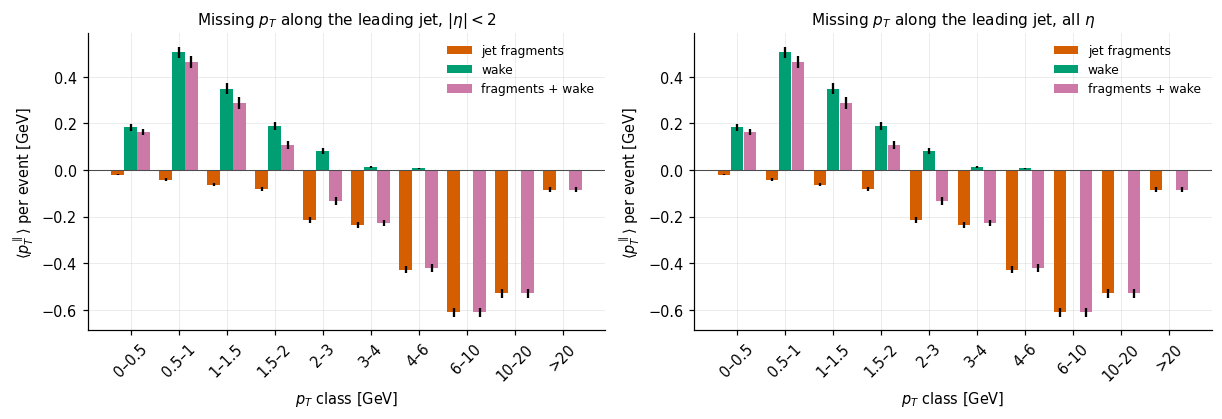

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.7), constrained_layout=True)
xt = np.arange(len(PT_C))
labels = [f"{PT_E[i]:g}–{PT_E[i + 1]:g}" if PT_E[i + 1] < 1e3 else f">{PT_E[i]:g}"
          for i in range(len(PT_C))]
for j, (title, sel) in enumerate(((r"$|\eta| < 2$", dict(band=slice(0, 3))),
                                  ("all $\\eta$", {}))):
    p = proj("totals", "pT_cos", keep=("pt",), group=0, **sel)
    for off, key in ((-0.27, "frag"), (0.0, "wake"), (0.27, "full")):
        m, e = stack(p, key)
        ax[j].bar(xt + off, -m, 0.26, yerr=e, color=SRC_C[key], label=LABEL[key])
    ax[j].axhline(0, color="0.3", lw=0.7)
    ax[j].set_xticks(xt, labels, rotation=45)
    tidy(ax[j], r"$p_T$ class [GeV]", r"$\langle p_T^{\parallel}\rangle$ per event [GeV]",
         f"Missing $p_T$ along the leading jet, {title}")
    ax[j].legend(fontsize=8)
    tot = {k: -stack(p, k)[0].sum() for k in ("frag", "wake", "full")}
    print(f"{title.replace('$', '')}: p_T^par fragments {tot['frag']:+.2f}, wake {tot['wake']:+.2f}, "
          f"total {tot['full']:+.2f} GeV; initiators {-wmean(E.pT_ini_par):+.2f} GeV")
plt.show()

## 8. Event by event: the wake against the deposit

With 400 oversamples per jet leg, the wake of a single event is measured to a few hadrons.
The profiles relate it to that event's parton- and hydro-level history from
`wake_observables.h5`: how much went in, when, and how long the fireball lived. They use
charged hadrons at |η| < 2 (bands 0–2 of `totals`) to stay clear of the forward region,
where the per-event noise is largest.

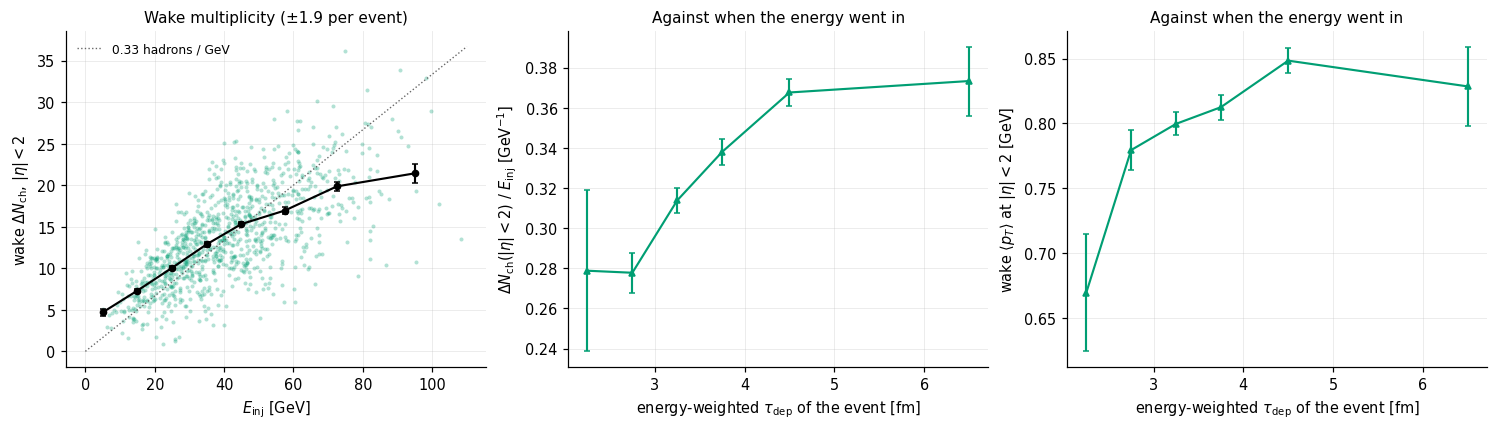

wake, all eta: 0.707 GeV of hadron energy per GeV received; |eta| < 2: 0.334 charged hadrons per GeV
correlations with wake dN_ch(|eta|<2): E_inj 0.69, lead-leg deposit 0.53, freeze-out delay 0.30, tau_dep 0.06


In [11]:
mid = dict(band=slice(0, 3))
wN = per_event(proj("totals", "N", group=1, **mid), "wake")
wP = per_event(proj("totals", "pT", group=1, **mid), "wake")
wE = per_event(proj("totals", "E", group=0), "wake")
eN = ev_err(proj("totals", "N", group=1, **mid), "wake")
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.8), constrained_layout=True)
edges = np.array([0, 10, 20, 30, 40, 50, 65, 80, 110])
x = E.E_inj_hydro
ax[0].scatter(x[G], wN[G], s=7, color=SRC_C["wake"], alpha=0.3, lw=0)
plot_profile(ax[0], x[G], wN[G], edges, E.w[G], color="k", marker="o")
slope = np.nansum((E.w * G) * wN) / np.nansum((E.w * G) * x)
ax[0].plot([0, 110], [0, 110 * slope], color="0.4", ls=":", lw=0.9,
           label=f"{slope:.2f} hadrons / GeV")
tidy(ax[0], r"$E_\mathrm{inj}$ [GeV]", r"wake $\Delta N_\mathrm{ch}$, $|\eta| < 2$",
     f"Wake multiplicity (±{np.median(eN[G]):.1f} per event)")
ax[0].legend(fontsize=8)

# hadrons per GeV and <pT> of the wake, in bins of the mean deposition time (ratio of sums)
tb = np.array([1.0, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 8.0])
ib = np.digitize(E.tau_dep, tb) - 1
for j, (num, den, ylab) in enumerate(((wN, x, r"$\Delta N_\mathrm{ch}(|\eta|<2)\ /\ E_\mathrm{inj}$ [GeV$^{-1}$]"),
                                      (wP, wN, r"wake $\langle p_T\rangle$ at $|\eta| < 2$ [GeV]"))):
    val, err = [], []
    for b in range(len(tb) - 1):
        sel = (ib == b) & G
        f = lambda w, sel=sel: np.nansum(w * sel * num) / np.nansum(w * sel * den)
        val.append(f(E.w.to_numpy() * G) if sel.sum() >= 5 else np.nan)
        err.append(boot(f, n=150) if sel.sum() >= 5 else np.nan)
    ax[1 + j].errorbar(0.5 * (tb[1:] + tb[:-1]), val, err, color=SRC_C["wake"], marker="^", ms=4,
                       lw=1.4, capsize=2)
    tidy(ax[1 + j], r"energy-weighted $\tau_\mathrm{dep}$ of the event [fm]", ylab,
         "Against when the energy went in")
plt.show()
print(f"wake, all eta: {np.nansum((E.w * G) * wE) / np.nansum((E.w * G) * x):.3f} GeV of hadron "
      f"energy per GeV received; |eta| < 2: {slope:.3f} charged hadrons per GeV")
cc = lambda a, b: np.corrcoef(a[G], b[G])[0, 1]
print(f"correlations with wake dN_ch(|eta|<2): E_inj {cc(x, wN):.2f}, lead-leg deposit "
      f"{cc(E.lead_E_dep_graph, wN):.2f}, freeze-out delay {cc(E.dtau_fo, wN):.2f}, "
      f"tau_dep {cc(E.tau_dep, wN):.2f}")

## 9. What to take from this

The numbers are for `AuAu_0_10_pth10-40_eta06_gridnorm` (kernel normalized on MUSIC's grid,
LBT double-count fix): 285 of 300 events, 95 per pTHat window, 400 jet-leg and 2000
background oversamples per event, 50 fragmentations. The averages are unweighted.

- **The bad run (§1).** Only job 0002 fails, and every check catches it. Its background has
  11.1× the jet leg's hadrons per sample and 3.2× its freeze-out cells, and its last frame
  still holds e = 2.8 GeV/fm³ (12 e_fo). In every good job the background is within 0.7% of
  the jet leg in multiplicity and 1.8% in cells. The pair-file test agrees with
  `wake_observables.h5` on every event.
- **Energy is conserved from partons to hadrons (§2).**
  - The wake's hadrons carry 38.5 ± 4.9 (sampling) ± 7.0 (files) GeV per event, against
    38.0 GeV that MUSIC_2 received: ratio 1.01.
  - The fragments give back the surviving partons exactly (0.999) once ColorlessHadronization's
    beam remnants are taken out. There are 0, 1 or 2 per event (90 / 130 / 65 events), 30 GeV per
    event on average.
  - Fragments + wake = 1.006 × the initiators' energy. The transverse momentum along the
    leading jet closes as well (0.82 against 0.83 GeV).
- **The wake spreads in rapidity.** 44% of its energy is at |η| < 1, against 64% of the
  deposit at |η_s| < 1. 30% is at |η| > 2, against 14%.
- **Spectrum (§3).** At |y| < 1 the wake adds 9.7 ± 0.2 charged hadrons per event to 1522,
  equally near (4.8) and away (4.9).
  - It is harder than the background: ⟨pT⟩ is 0.85 against 0.54 GeV (fragments: 1.71 GeV).
  - Relative to the background it grows from 0.3% at 0.1 GeV to ~5% at 3 GeV.
  - Above 2.1 GeV the fragments dominate.
- **Chemistry (§4).** The wake has thermal chemistry: K/π = 0.170 ± 0.013 (background 0.189),
  p/π = 0.092 ± 0.006 (0.084), Λ/π = 0.055 (0.051). String fragmentation gives 0.128, 0.065 and
  0.023. At fixed pT the wake's p/π is below the background's (1.1 against 2.0 at 2.3 GeV).
  The wake is a flowing thermal source, but with less radial boost at a given pT.
- **Around the jet (§5).**
  - The wake peaks along the leading jet and along its partner (4.3 and 3.8 charged hadrons
    within π/3, |Δη| < 1). Near the jet it is 1–12% of the background, rising with pT.
  - It is broader than the fragments in Δη (half width ~1 below 1 GeV).
  - There is **no significant depletion** anywhere, not even behind a leading jet that
    dominates the deposit. For those 27 events the region behind it has −0.13 ± 0.27 ± 0.43
    hadrons at 0–1 GeV. A diffusion wake, if there is one, is below the sensitivity of this
    sample.
- **Jet shape (§6).** The wake adds little at r < 0.2 and doubles to triples ρ(r) at
  r = 0.5–1. Its 1–2 GeV part peaks at r ≈ 0.45.
  - The wake pT inside R is 2.2 GeV at R = 0.4 (20% of the leading leg's deposit), 5.4 GeV at
    0.8 (49%) and 7.6 GeV at 1.5 (70%).
  - The fragments hold 11.3 GeV inside 0.4, against 14.2 GeV of surviving parton energy there.
- **Missing pT (§7).** The fragments carry −2.4 GeV along the leading jet, at pT > 2 GeV. The
  wake carries +1.6 GeV back toward the partner, at 0.5–2 GeV. In 156 of 285 events the leading
  leg makes less than 30% of the event's deposit. The sum, −0.82 GeV, is the initiators' −0.83.
- **Event by event (§8).**
  - The wake gives 0.34 charged hadrons at |η| < 2 per GeV received (correlation 0.53), rising
    less than linearly at large deposits.
  - Later deposits give harder wakes: ⟨pT⟩ goes from 0.68 to 1.03 GeV between τ_dep ≈ 2 and
    6.5 fm, and they keep more of it at midrapidity.

**Caveats.**
- The sample is small: 285 events in 19 files, so the file-bootstrap errors are themselves
  uncertain.
- The jet axis is the leading initiator parton, not a reconstructed jet.
- ColorlessHadronization's remnant strings put fragments at large |Δη| (up to 10× at
  |Δη| ≈ 3.5, §2). They affect the jet shape beyond ΔR ≈ 1.5 and the fragments' forward
  bands, not the wake.
- iSS alone, with no hadronic afterburner: hadronic rescattering of the wake is not included.
- The background noise is taken as fully correlated among the events that share it, so the
  sampling errors are upper bounds. This holds for independently sampled legs, as here. For
  common-seed productions the bkg + wake and wake errors come from batch means instead (see
  the introduction).